In [5]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
import yaml
from tqdm import tqdm
import torchvision.transforms.v2 as v2
from copy import deepcopy
import sys
sys.path.append("/n/home11/sambt/phlab-neurips25/")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

from sklearn.metrics import roc_auc_score, top_k_accuracy_score
from utils.plotting import make_corner
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# embedding without anomaly

NBKG 49781
NSIG 9600


100%|██████████| 10/10 [00:29<00:00,  2.90s/it]


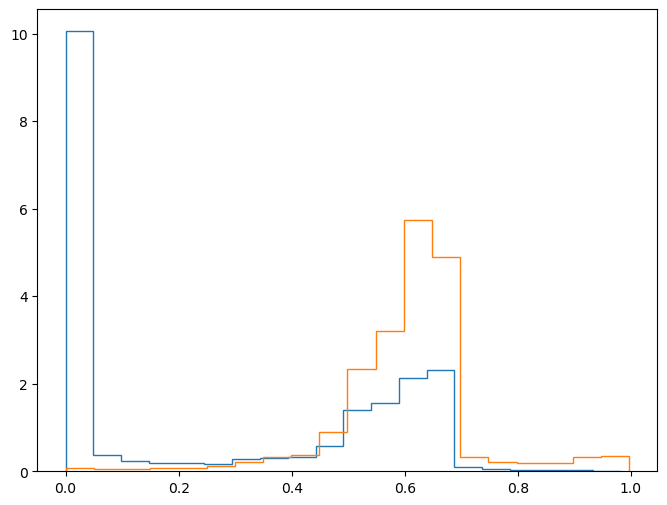

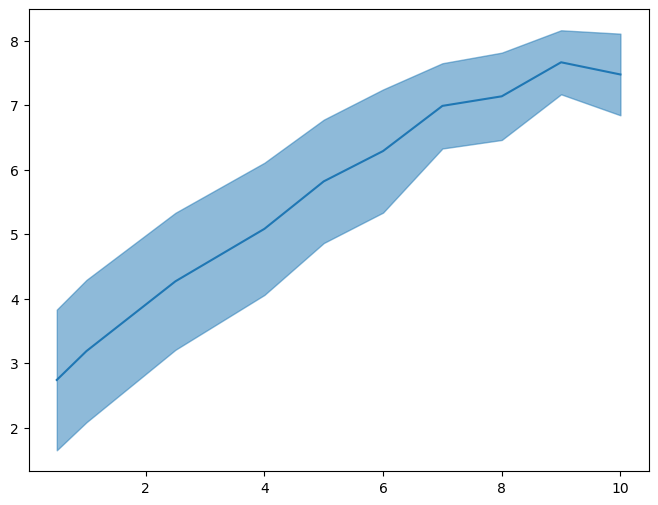

In [6]:
f = "/n/holystore01/LABS/iaifi_lab/Lab/phlab-neurips25/GWAK/results/classifier/classifier_woAnomaly_classbalanced.npz"
x = np.load(f)
labels = x['label']
bkg_test_preds = x['predict'][labels==0]
sig_test_preds = x['predict'][labels==1]
print("NBKG",len(bkg_test_preds))
print("NSIG",len(sig_test_preds))

plt.figure(figsize=(8,6))
#bins = np.linspace(0,1,20)
bins = 20
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.005,0.01,0.025,0.04,0.05,0.06,0.07,0.08,0.09,0.1]
iNBkg = 4000
iNRef = 20_000
Ntoys = 100

targ_per_bin = 2
iNBins = int(iNBkg/targ_per_bin)
#iNBins = 800

pvalues = []
psigmas = []
zscores = []
zsigmas = []
xmin = 0
xmax = 1
plot = False
philBin=True
for sf in tqdm(sig_fracs):
    ps = []
    zs = []
    ts = []
    for i in range(Ntoys):
        ref_bkg = np.random.choice(bkg_test_preds,size=iNBkg+iNRef,replace=False)
        iRef = ref_bkg[:iNRef]
        iBkg = ref_bkg[iNRef:iNRef+iNBkg]
        iNSig = int(sf*iNBkg)
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=False)
        iData = np.concatenate([iBkg,iSig])
        #print(iSig.shape)
        #print(iBkg.shape)
        #print(iRef.shape)
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=iNBins,xmin=xmin,xmax=xmax,plot=plot,philBin=philBin)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

np.savez("gwak_idealZscores_vanillaSpace.npz",zscores=zscores,fracs=sig_fracs)

# embedding with anomaly

NBKG 49768
NSIG 6413


  0%|          | 0/10 [00:00<?, ?it/s]


ValueError: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.

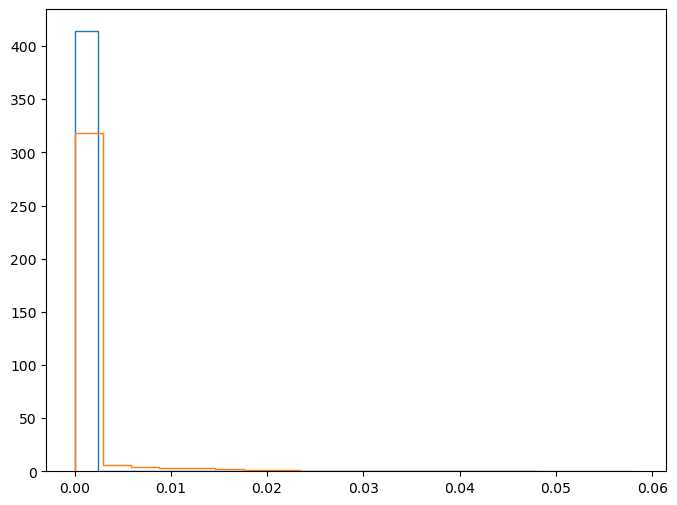

In [15]:
f = "/n/holystore01/LABS/iaifi_lab/Lab/phlab-neurips25/GWAK/results/classifier/classifier_wAnomaly_classbalanced.npz"
x = np.load(f)
labels = x['label']
bkg_test_preds = x['predict'][labels==0]
sig_test_preds = x['predict'][labels==1]
print("NBKG",len(bkg_test_preds))
print("NSIG",len(sig_test_preds))

plt.figure(figsize=(8,6))
#bins = np.linspace(0,1,20)
bins = 20
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.005,0.01,0.025,0.04,0.05,0.06,0.07,0.08,0.09,0.1]
iNBkg = 4000
iNRef = 20_000
Ntoys = 100

targ_per_bin = 2
iNBins = int(iNBkg/targ_per_bin)
#iNBins = 800

pvalues = []
psigmas = []
zscores = []
zsigmas = []
xmin = 0
xmax = 1
plot = False
philBin=True
for sf in tqdm(sig_fracs):
    ps = []
    zs = []
    for i in range(Ntoys):
        ref_bkg = np.random.choice(bkg_test_preds,size=iNBkg+iNRef,replace=False)
        iRef = ref_bkg[:iNRef]
        iBkg = ref_bkg[iNRef:iNRef+iNBkg]
        iNSig = int(sf*iNBkg)
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=False)
        iData = np.concatenate([iBkg,iSig])
        #print(iSig.shape)
        #print(iBkg.shape)
        #print(iRef.shape)
        if sf == 0.05:
            iData *= 10
            iRef *= 10
            factor=10
        else:
            factor=1
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=iNBins,xmin=factor*xmin,xmax=factor*xmax,plot=plot,philBin=philBin)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

np.savez("gwak_idealZscores_spaceWithAnomaly.npz",zscores=zscores,fracs=sig_fracs)

# vary dims

NBKG 49781
NSIG 9600


100%|██████████| 10/10 [00:29<00:00,  2.96s/it]


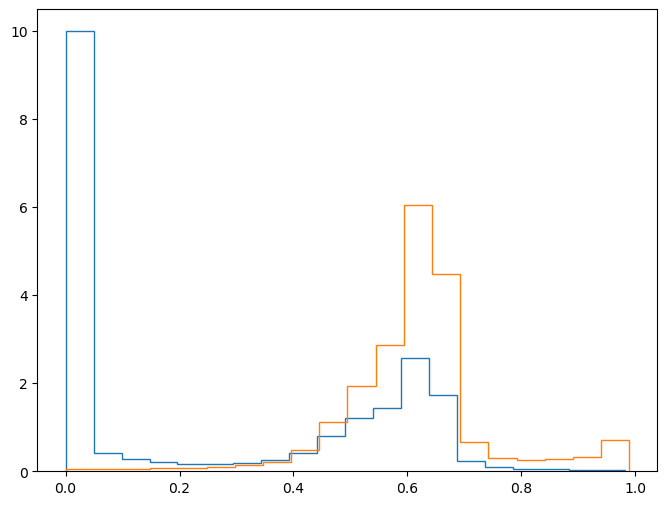

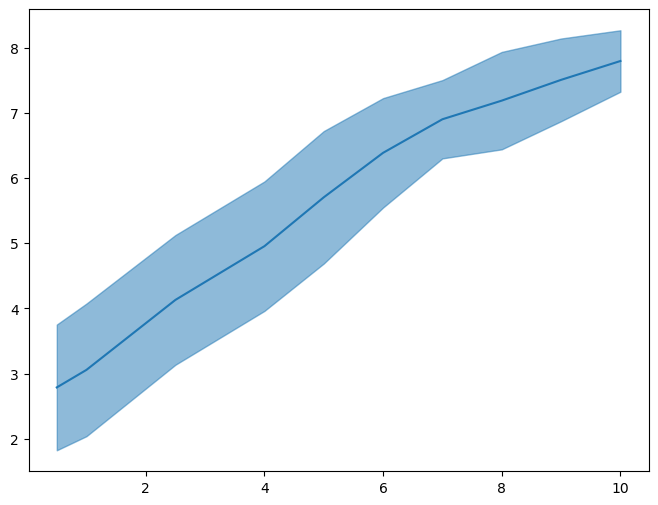

In [11]:
dim = 8

f = f"/n/holystore01/LABS/iaifi_lab/Lab/phlab-neurips25/GWAK/results/dim{dim}/classifier_woAnomaly_classbalanced.npz"
x = np.load(f)
labels = x['label']
bkg_test_preds = x['predict'][labels==0]
sig_test_preds = x['predict'][labels==1]
print("NBKG",len(bkg_test_preds))
print("NSIG",len(sig_test_preds))

plt.figure(figsize=(8,6))
#bins = np.linspace(0,1,20)
bins = 20
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.005,0.01,0.025,0.04,0.05,0.06,0.07,0.08,0.09,0.1]
iNBkg = 4000
iNRef = 20_000
Ntoys = 100

targ_per_bin = 2
iNBins = int(iNBkg/targ_per_bin)
#iNBins = 800

pvalues = []
psigmas = []
zscores = []
zsigmas = []
xmin = 0
xmax = 1
plot = False
philBin=True
for sf in tqdm(sig_fracs):
    ps = []
    zs = []
    ts = []
    for i in range(Ntoys):
        ref_bkg = np.random.choice(bkg_test_preds,size=iNBkg+iNRef,replace=False)
        iRef = ref_bkg[:iNRef]
        iBkg = ref_bkg[iNRef:iNRef+iNBkg]
        iNSig = int(sf*iNBkg)
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=False)
        iData = np.concatenate([iBkg,iSig])
        #print(iSig.shape)
        #print(iBkg.shape)
        #print(iRef.shape)
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=iNBins,xmin=xmin,xmax=xmax,plot=plot,philBin=philBin)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

np.savez(f"gwak_idealZscores_vanillaSpace_dim{dim}.npz",zscores=zscores,fracs=sig_fracs)

NBKG 49744
NSIG 6437


100%|██████████| 10/10 [00:29<00:00,  2.92s/it]


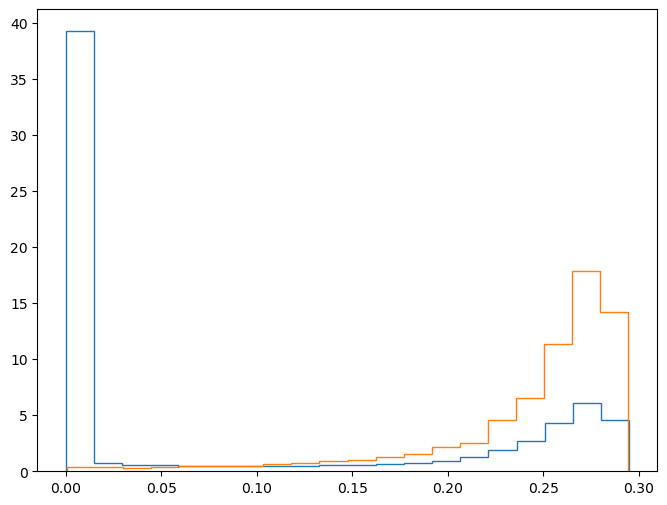

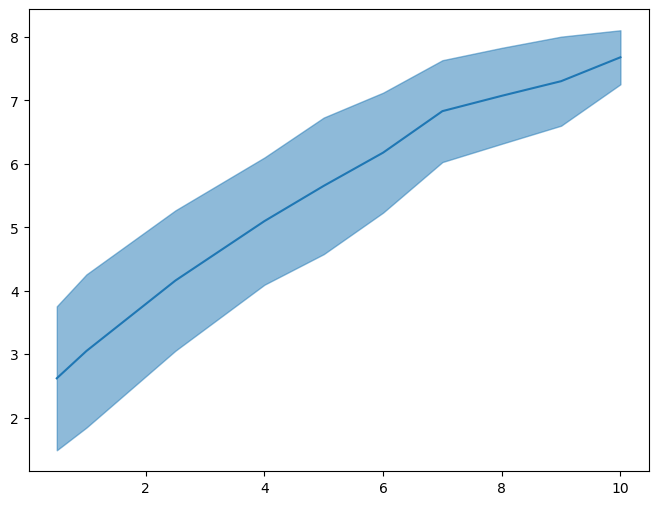

In [14]:
dim = 32

f = f"/n/holystore01/LABS/iaifi_lab/Lab/phlab-neurips25/GWAK/results/dim{dim}/classifier_wAnomaly_classbalanced_v2.npz"
x = np.load(f)
labels = x['label']
bkg_test_preds = x['predict'][labels==0]
sig_test_preds = x['predict'][labels==1]
print("NBKG",len(bkg_test_preds))
print("NSIG",len(sig_test_preds))

plt.figure(figsize=(8,6))
#bins = np.linspace(0,1,20)
bins = 20
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.005,0.01,0.025,0.04,0.05,0.06,0.07,0.08,0.09,0.1]
iNBkg = 4000
iNRef = 20_000
Ntoys = 100

targ_per_bin = 2
iNBins = int(iNBkg/targ_per_bin)
#iNBins = 800

pvalues = []
psigmas = []
zscores = []
zsigmas = []
xmin = 0
xmax = 1
plot = False
philBin=True
for sf in tqdm(sig_fracs):
    ps = []
    zs = []
    for i in range(Ntoys):
        ref_bkg = np.random.choice(bkg_test_preds,size=iNBkg+iNRef,replace=False)
        iRef = ref_bkg[:iNRef]
        iBkg = ref_bkg[iNRef:iNRef+iNBkg]
        iNSig = int(sf*iNBkg)
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=False)
        iData = np.concatenate([iBkg,iSig])
        #print(iSig.shape)
        #print(iBkg.shape)
        #print(iRef.shape)
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=iNBins,xmin=xmin,xmax=xmax,plot=plot,philBin=philBin)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

np.savez(f"gwak_idealZscores_spaceWithAnomaly_dim{dim}.npz",zscores=zscores,fracs=sig_fracs)